<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/PM25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

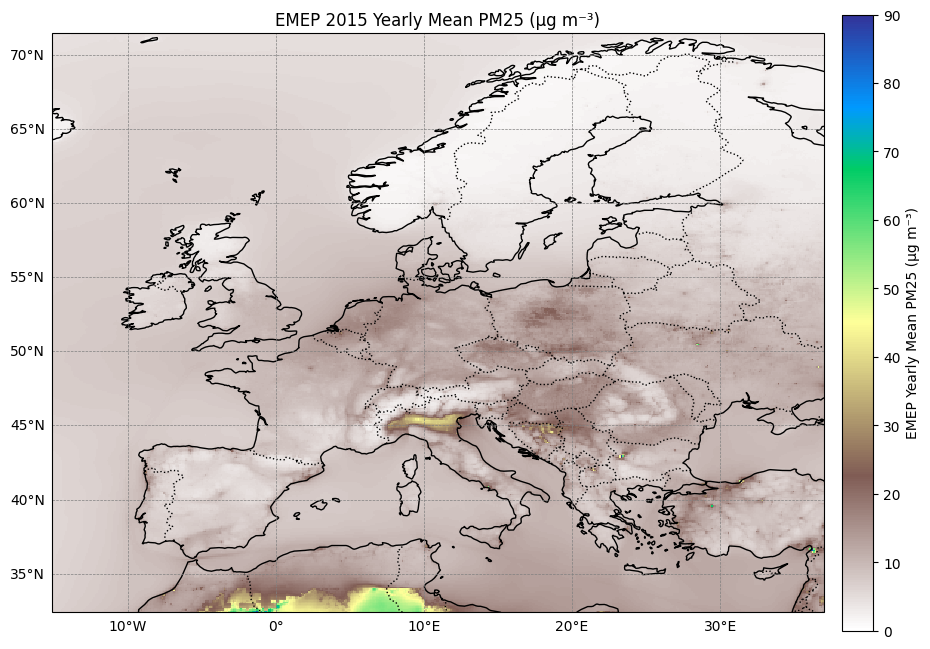

In [30]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP O₃ NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2015.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract O₃ values (μg m⁻³)
NO2 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization ===
norm = mcolors.Normalize(0, 90)  # adjust if needed

# Create a figure with a map projection
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot the O₃ concentration using pcolormesh
mesh = ax.pcolormesh(
    Lon,
    Lat,
    NO2,
    cmap='terrain_r',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM25 (μg m⁻³)")

# Add coastlines and borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Set labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2015 Yearly Mean PM25 (μg m⁻³)")

# Show plot
plt.show()

# Close dataset
ds.close()

In [31]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# ======================================================
# 1. Load EMEP NetCDF
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lats = ds["lat"].values
lons = ds["lon"].values

# Δημιουργία EMEP grid (cell centres)
lon_grid, lat_grid = np.meshgrid(lons, lats)
grid_points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
grid_points_rad = np.radians(grid_points)

# ======================================================
# 2. Load station CSV
# ======================================================
df = pd.read_csv("yearly_PM25_2015.csv")

station_coords = np.column_stack([df["Latitude"], df["Longitude"]])
station_coords_rad = np.radians(station_coords)

# ======================================================
# 3. Nearest-neighbour matching (station → EMEP cell)
# ======================================================
tree = BallTree(grid_points_rad, metric="haversine")
dist_rad, idx = tree.query(station_coords_rad, k=1)

# Απόσταση σε km
df["distance_km"] = dist_rad[:, 0] * 6371.0

# Αντιστοίχιση κελιού
df["emep_lat"] = grid_points[idx[:, 0], 0]
df["emep_lon"] = grid_points[idx[:, 0], 1]

# ======================================================
# 4. FAIRMODE spatial filtering
#    → κρατάμε 1 σταθμό ανά κελί (τον πλησιέστερο)
# ======================================================
df_unique = (
    df
    .sort_values("distance_km")
    .drop_duplicates(subset=["emep_lat", "emep_lon"])
    .reset_index(drop=True)
)

# ======================================================
# 5. Έλεγχοι
# ======================================================
print("Αρχικοί σταθμοί:", len(df))
print("Σταθμοί μετά το spatial filtering:", len(df_unique))

# Προαιρετικός έλεγχος
max_per_cell = (
    df_unique
    .groupby(["emep_lat", "emep_lon"])
    .size()
    .max()
)
print("Μέγιστοι σταθμοί ανά κελί μετά τον καθαρισμό:", max_per_cell)

# ======================================================
# 6. Αποθήκευση
# ======================================================
df_unique.to_csv("yearly_PM25_2015_1station.csv", index=False)

Αρχικοί σταθμοί: 947
Σταθμοί μετά το spatial filtering: 798
Μέγιστοι σταθμοί ανά κελί μετά τον καθαρισμό: 1


In [32]:
import pandas as pd

# Load CSV
stations = pd.read_csv("yearly_PM25_2015_1station.csv")

# Remove southern outlier(s): Réunion
stations_clean = stations[
    (stations["Latitude"] >= 32.45) &
    (stations["Latitude"] <= 71.45) &
    (stations["Longitude"] >= -15.05) &
    (stations["Longitude"] <= 36.95)
]

# Sanity check
print("Original stations:", len(stations))
print("After removal:", len(stations_clean))
print("Latitude min:", stations_clean["Latitude"].min())

stations_clean.to_csv("yearly_PM25_2015_CS.csv", index=False)

Original stations: 798
After removal: 798
Latitude min: 34.6817


In [33]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# --- Load Data ---
nc_file_path = "EMEP_yearly_2015.nc"
csv_file_path = "yearly_PM25_2015_CS.csv"

# Load NetCDF Data
nc_data = xr.open_dataset(nc_file_path)
lon_values = nc_data["lon"].values  # Grid center longitudes
lat_values = nc_data["lat"].values  # Grid center latitudes
pm25_grid = nc_data["SURF_ug_PM25_rh50"].values.squeeze()  # Remove time dimension

# Create grid points (lat, lon) and flatten PM2.5 values
lon_grid, lat_grid = np.meshgrid(lon_values, lat_values)
grid_points_deg = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))  # For BallTree: (lat, lon)
grid_points_rad = np.radians(grid_points_deg)
pm25_values = pm25_grid.ravel()

# Load Station Data
station_data = pd.read_csv(csv_file_path)
station_lons = station_data["Longitude"].values
station_lats = station_data["Latitude"].values
station_observed_pm25 = station_data["Average"].values
station_coords_deg = np.column_stack((station_lats, station_lons))  # (lat, lon)
station_coords_rad = np.radians(station_coords_deg)

# --- Nearest Grid Cell Matching (Haversine) ---
tree = BallTree(grid_points_rad, metric="haversine")
distances_rad, indices = tree.query(station_coords_rad, k=1)
nearest_indices = indices.flatten()
nearest_grid_coords = grid_points_deg[nearest_indices]  # Still (lat, lon)
nearest_pm25_values = pm25_values[nearest_indices]

# --- Create Output DataFrame ---
grid_cell_indices = list(zip(nearest_grid_coords[:, 1], nearest_grid_coords[:, 0]))  # (lon, lat)

df_matched = pd.DataFrame({
    "lon": station_lons,
    "lat": station_lats,
    "nearest_grid_lon": nearest_grid_coords[:, 1],
    "nearest_grid_lat": nearest_grid_coords[:, 0],
    "grid_cell_index": grid_cell_indices,
    "SURF_ug_PM25_rh50": station_observed_pm25,
    "nearest_SURF_ug_PM25_rh50": nearest_pm25_values
})

# Ensure correct column order
df_matched = df_matched[[
    "lon", "lat", "nearest_grid_lon", "nearest_grid_lat",
    "grid_cell_index", "SURF_ug_PM25_rh50", "nearest_SURF_ug_PM25_rh50"
]]

# --- Save Final CSV ---
df_matched.to_csv("basePM25nearest_grid.csv", index=False)

print(" Done. File saved as 'basePM25nearest_grid.csv'")

 Done. File saved as 'basePM25nearest_grid.csv'


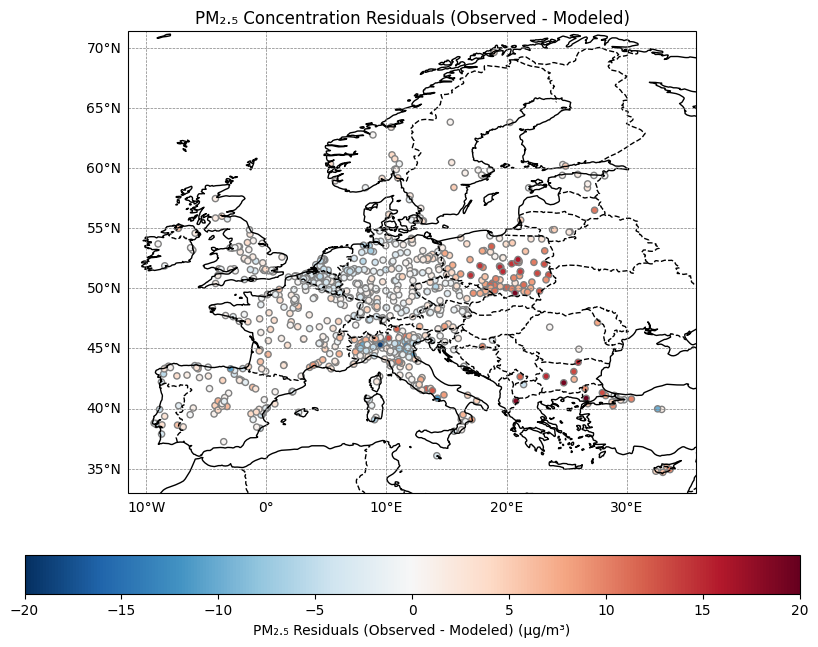

In [34]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Φόρτωση των δεδομένων
stations = pd.read_csv("basePM25nearest_grid.csv")

# Υπολογισμός των residuals ως (Observed - Modeled)
stations["PM25_residuals"] = stations["SURF_ug_PM25_rh50"] - stations["nearest_SURF_ug_PM25_rh50"]

# Ορισμός των ορίων της χρωματικής κλίμακας
cbar_min = -20
cbar_max = 20

# Δημιουργία χάρτη
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Προσθήκη συνόρων και ακτογραμμών
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Προσθήκη γραμμών πλέγματος
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Αφαίρεση ετικετών στην κορυφή
gl.right_labels = False  # Αφαίρεση ετικετών στα δεξιά

# Προβολή των residuals NO₂ με χρωματική κλίμακα RdBu (το 0 στο λευκό)
sc = ax.scatter(
    stations["lon"],
    stations["lat"],
    c=stations["PM25_residuals"],
    cmap="RdBu_r",
    vmin=cbar_min,
    vmax=cbar_max,
    edgecolors="grey",
    s=20,
    transform=ccrs.PlateCarree()
)

# Προσθήκη οριζόντιας χρωματικής κλίμακας κάτω από το σχήμα
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.1)
cbar.set_label("PM₂.₅ Residuals (Observed - Modeled) (µg/m³)")

# Τίτλος
ax.set_title("PM₂.₅ Concentration Residuals (Observed - Modeled)")

# Εμφάνιση χάρτη
plt.show()

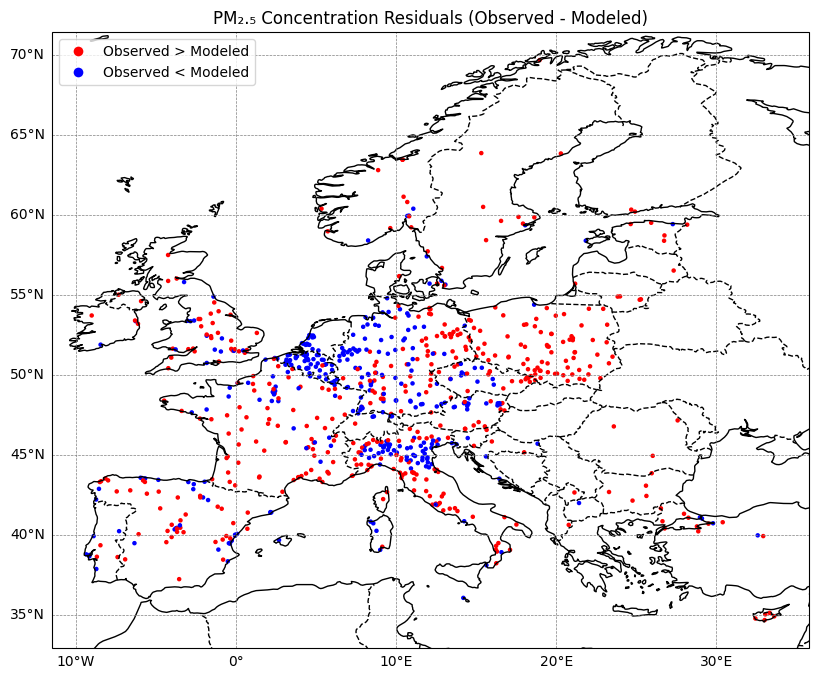

In [35]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from matplotlib.lines import Line2D

# Φόρτωση των δεδομένων
stations = pd.read_csv("basePM25nearest_grid.csv")

# Υπολογισμός των residuals ως (Observed - Modeled)
stations["PM25_residuals"] = stations["SURF_ug_PM25_rh50"] - stations["nearest_SURF_ug_PM25_rh50"]

# Ορισμός χρώματος ανάλογα με το πρόσημο των residuals
colors = stations["PM25_residuals"].apply(lambda x: "red" if x > 0 else "blue")

# Δημιουργία χάρτη
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Προσθήκη συνόρων και ακτογραμμών
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Προσθήκη γραμμών πλέγματος
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Αφαίρεση ετικετών στην κορυφή
gl.right_labels = False  # Αφαίρεση ετικετών στα δεξιά

# Προβολή των residuals PM₂.₅ με δύο χρώματα (κόκκινο = Observed > Modeled, μπλε = Observed < Modeled)
sc = ax.scatter(
    stations["lon"],
    stations["lat"],
    c=colors,
    edgecolors= None,
    s=5,  # Σταθερό μέγεθος σημείων
    transform=ccrs.PlateCarree()
)

# Προσθήκη υπομνήματος
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label="Observed > Modeled"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label="Observed < Modeled")
]
ax.legend(handles=legend_elements, loc="upper left")

# Τίτλος
ax.set_title("PM₂.₅ Concentration Residuals (Observed - Modeled)")

# Εμφάνιση χάρτη
plt.show()

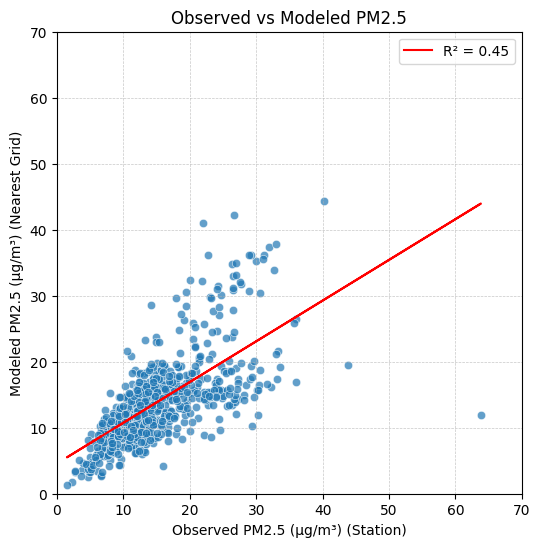

Mean Absolute Error (MAE): 3.47
Root Mean Squared Error (RMSE): 5.22


In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Import missing functions

# Load the dataset
stations = pd.read_csv("basePM25nearest_grid.csv")

# Extract observed and modeled PM2.5 values
observed_pm25 = stations["SURF_ug_PM25_rh50"]
modeled_pm25 = stations["nearest_SURF_ug_PM25_rh50"]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(observed_pm25, modeled_pm25)

# Calculate R-squared
r_squared = r_value**2

# Create the scatter plot with grid
plt.figure(figsize=(6, 6))
sns.scatterplot(x=observed_pm25, y=modeled_pm25, alpha=0.7)

# Plot the regression line with R² label
plt.plot(observed_pm25, slope * observed_pm25 + intercept, color='red', label=f"R² = {r_squared:.2f}")

# Labels, title, and grid
plt.xlabel("Observed PM2.5 (µg/m³) (Station)")
plt.xlim(0, 70)
plt.ylim(0, 70)
plt.ylabel("Modeled PM2.5 (µg/m³) (Nearest Grid)")
plt.title("Observed vs Modeled PM2.5")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()

# Compute error metrics
mae = mean_absolute_error(observed_pm25, modeled_pm25)
rmse = np.sqrt(mean_squared_error(observed_pm25, modeled_pm25))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# IDW - Additive Method

In [38]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import itertools
from sklearn.neighbors import BallTree

# === Load CSV Data ===
csv_file_path = "basePM25nearest_grid.csv"
df = pd.read_csv(csv_file_path)

# Compute bias (Observed - Modeled at nearest grid)
df["bias"] = df["SURF_ug_PM25_rh50"] - df["nearest_SURF_ug_PM25_rh50"]

# === Load NetCDF Data ===
netcdf_path = "EMEP_yearly_2015.nc"
dataset = nc.Dataset(netcdf_path, "r")

lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
pm25_modeled = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]  # (time, lat, lon) -> [0, :, :]

# Convert degrees to radians for Haversine
lon_rad = np.radians(lon)
lat_rad = np.radians(lat)

# Grid points
lon_mesh, lat_mesh = np.meshgrid(lon_rad, lat_rad)
points_grid = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])  # (lat, lon) σε radians

# === Station points at nearest grid cells (in radians) ===
station_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])
bias_values = df["bias"].values

# === Grid Search for best (p, k) ===
p_values = np.arange(0.1, 5.1, 0.1).tolist()
k_values = np.arange(2, 41, 1).tolist()

kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = []
best_rmse = float("inf")
best_params = None

with tqdm(total=len(p_values) * len(k_values), desc="Grid Search for IDW Additive") as pbar:
    for p, k in itertools.product(p_values, k_values):
        fold_rmses = []
        for train_index, test_index in kf.split(station_points):
            train_points, test_points = station_points[train_index], station_points[test_index]
            train_values, test_values = bias_values[train_index], bias_values[test_index]

            train_tree = BallTree(train_points, metric="haversine")
            predicted_bias = []

            for test_point in test_points:
                dists, idxs = train_tree.query([test_point], k=k)
                dists = dists.flatten()
                idxs = idxs.flatten()

                if np.any(dists == 0):
                    predicted_bias.append(train_values[idxs[dists == 0]][0])
                else:
                    weights = 1 / (dists ** p)
                    weights /= np.sum(weights)
                    interpolated_bias = np.sum(weights * train_values[idxs])
                    predicted_bias.append(interpolated_bias)

            fold_rmse = np.sqrt(mean_squared_error(test_values, predicted_bias))
            fold_rmses.append(fold_rmse)

        mean_rmse = np.mean(fold_rmses)
        results.append((p, k, mean_rmse))
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_params = (p, k)
        pbar.update(1)

# Save Grid Search Results
results_df = pd.DataFrame(results, columns=["p", "k", "RMSE"])
results_df.to_csv("BaseCase_PM25_Y_IDW_ADD_Val.csv", index=False)
print(f"\nBest parameters found: p={best_params[0]}, k={best_params[1]} with RMSE={best_rmse:.4f}")

# === Apply IDW with Best Parameters ===
def idw_inverse_distance(grid_points, station_points, values, p, k):
    tree = BallTree(station_points, metric="haversine")
    dists, idxs = tree.query(grid_points, k=k)
    zero_dist_mask = dists == 0
    interpolated = np.zeros(grid_points.shape[0])

    interpolated[zero_dist_mask[:, 0]] = values[idxs[zero_dist_mask[:, 0], 0]]
    non_zero_idx = ~zero_dist_mask[:, 0]
    dists_non_zero = dists[non_zero_idx]
    idxs_non_zero = idxs[non_zero_idx]

    weights = 1 / (dists_non_zero ** p)
    weights /= np.sum(weights, axis=1, keepdims=True)
    interpolated[non_zero_idx] = np.sum(weights * values[idxs_non_zero], axis=1)
    return interpolated

print("\nInterpolating bias field with best hyperparameters...")
interpolated_bias = idw_inverse_distance(points_grid, station_points, bias_values, best_params[0], best_params[1])
interpolated_bias = interpolated_bias.reshape(pm25_modeled.shape)

# === Save Interpolated Bias to NetCDF ===
output_path = "BaseCase_PM25_Y_IDW_ADD.nc"
new_dataset = nc.Dataset(output_path, "w", format="NETCDF4")
new_dataset.createDimension("lat", lat.shape[0])
new_dataset.createDimension("lon", lon.shape[0])

lat_var = new_dataset.createVariable("lat", "f4", ("lat",))
lon_var = new_dataset.createVariable("lon", "f4", ("lon",))
bias_var = new_dataset.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

bias_var.setncatts(dataset.variables["SURF_ug_PM25_rh50"].__dict__)
lat_var[:] = lat
lon_var[:] = lon
bias_var[:, :] = interpolated_bias

new_dataset.description = "Interpolated Bias using Inverse Distance Weighting (Optimized p & k, Nearest Grid, Haversine BallTree)"
new_dataset.close()
print("Interpolated Bias Saved to:", output_path)

# === LOSO Validation ===
print("\nComputing LOSO RMSE, MAE, R²...")
loso_predictions = []
loso_actuals = []

for i in tqdm(range(len(station_points)), desc="LOSO Progress"):
    train_points = np.delete(station_points, i, axis=0)
    train_values = np.delete(bias_values, i)
    tree = BallTree(train_points, metric="haversine")
    test_point = station_points[i].reshape(1, -1)
    dists, idxs = tree.query(test_point, k=best_params[1])
    dists = dists.flatten()
    idxs = idxs.flatten()

    if np.any(dists == 0):
        pred = train_values[idxs[dists == 0]][0]
    else:
        weights = 1 / (dists ** best_params[0])
        weights /= np.sum(weights)
        pred = np.sum(weights * train_values[idxs])

    loso_predictions.append(pred)
    loso_actuals.append(bias_values[i])

# Metrics
loso_rmse = np.sqrt(mean_squared_error(loso_actuals, loso_predictions))
loso_mae = mean_absolute_error(loso_actuals, loso_predictions)
loso_r2 = r2_score(loso_actuals, loso_predictions)

print(f"\nLOSO RMSE: {loso_rmse:.4f}")
print(f"LOSO MAE : {loso_mae:.4f}")
print(f"LOSO R²  : {loso_r2:.4f}")

Grid Search for IDW Additive: 100%|██████████| 1950/1950 [04:45<00:00,  6.82it/s]



Best parameters found: p=0.9, k=18 with RMSE=3.6284

Interpolating bias field with best hyperparameters...
Interpolated Bias Saved to: BaseCase_PM25_Y_IDW_ADD.nc

Computing LOSO RMSE, MAE, R²...


LOSO Progress: 100%|██████████| 798/798 [00:00<00:00, 988.90it/s]


LOSO RMSE: 3.7586
LOSO MAE : 2.4392
LOSO R²  : 0.4584


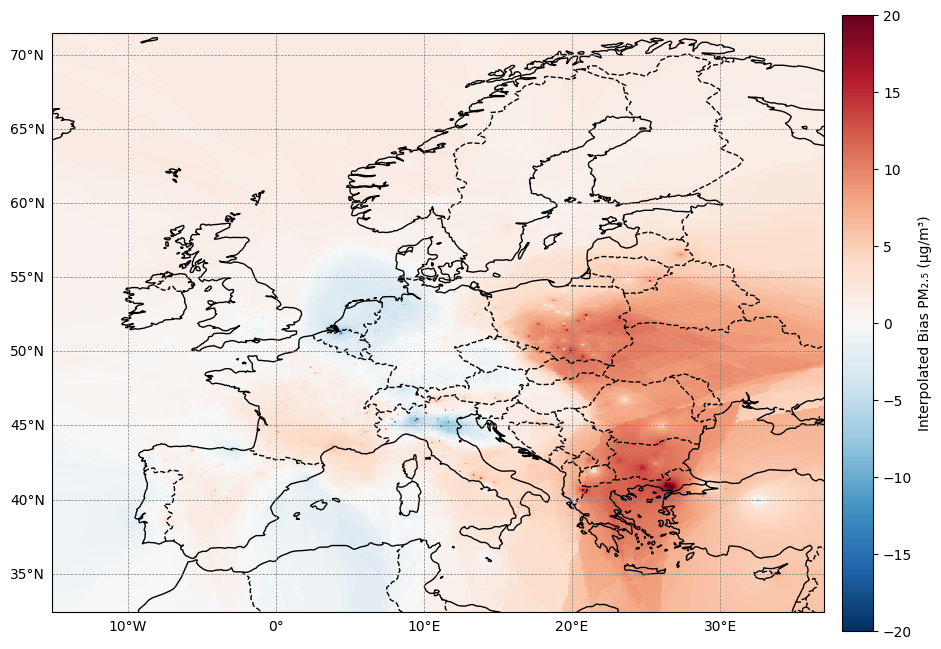

In [40]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias NetCDF File ===
bias_netcdf_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # File already saved
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias (residuals)
interpolated_bias = ds_bias["Interpolated_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -20  # Minimum bias value for color scale
cbar_max = 20  # Maximum bias value for color scale

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias
im = ax.pcolormesh(lon, lat, interpolated_bias, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias PM₂.₅ (µg/m³)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()


In [45]:

import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"
corrected_nc_path = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"

# === Load the Original Modeled PM₂.₅ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

    # Load the interpolated bias
    interpolated_bias = bias_nc.variables["Interpolated_Bias"][:]

    # === Compute the Unbiased PM₂.₅ ===
    pm25_corrected = pm25_original + interpolated_bias  # Apply the bias correction

    # === Save the Corrected PM₂.₅ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_rh50_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original PM₂.₅ variable
        pm25_var.setncatts(original_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_corrected  # Store corrected PM₂.₅

print(" Bias correction completed successfully!")
print(" Corrected PM₂.₅ NetCDF file saved as:", corrected_nc_path)


 Bias correction completed successfully!
 Corrected PM₂.₅ NetCDF file saved as: BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc


In [46]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"  # Your original file
output_file = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_rh50_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

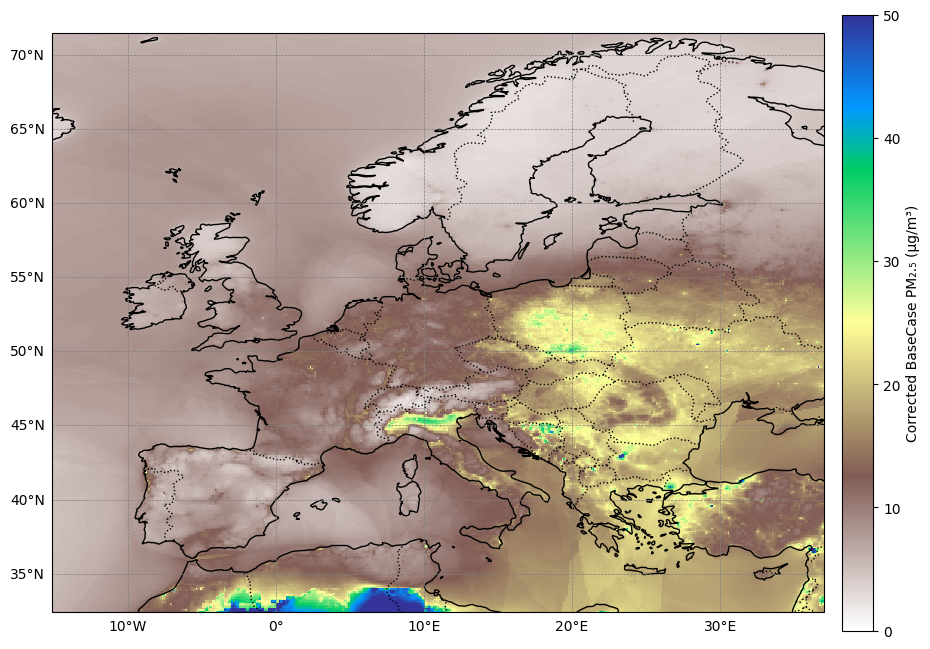

In [47]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected BaseCase PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [48]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2022.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Original base case (raw modeled)
corrected_scenario_nc_path = "Scenario_Corrected_PM25_Y_IDW_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]  # Perturbed scenario PM2.5
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]  # Interpolated residuals (IR_BC)
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # Raw modeled PM2.5 (BC)

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)


Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected_PM25_Y_IDW_ADD.nc


In [49]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_PM25_Y_IDW_ADD.nc"  # Your original file
output_file = "Scen_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: Scen_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators version 5.0

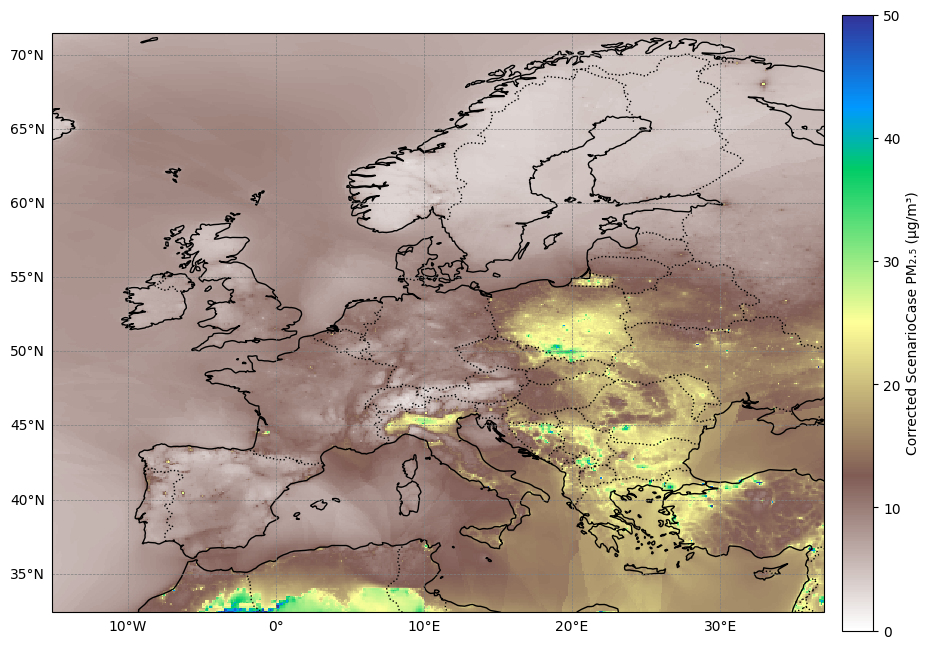

In [50]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected ScenarioCase PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# IDW- Multiplicative Mehod

In [52]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from sklearn.neighbors import BallTree
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import itertools

# === Load CSV Data ===
csv_file_path = "basePM25nearest_grid.csv"
df = pd.read_csv(csv_file_path)

# Compute bias ratio (Observed / Modeled)
df["bias_ratio"] = df["SURF_ug_PM25_rh50"] / df["nearest_SURF_ug_PM25_rh50"]

# === Load NetCDF Data ===
netcdf_path = "EMEP_yearly_2015.nc"
dataset = nc.Dataset(netcdf_path, "r")

lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
pm25_modeled = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]

# Create Meshgrid for Grid Points
lon_mesh, lat_mesh = np.meshgrid(lon, lat)
points_grid = np.column_stack([np.radians(lat_mesh.ravel()), np.radians(lon_mesh.ravel())])  # Convert to radians for BallTree

# Prepare Station Data
station_points = np.column_stack([np.radians(df["nearest_grid_lat"].values), np.radians(df["nearest_grid_lon"].values)])  # Convert to radians
bias_ratios = df["bias_ratio"].values

# === Define Hyperparameter Search Range for `p` and `k` ===
p_values = np.arange(0.1, 5.1, 0.1).tolist()  # p (Power Parameter)
k_values = np.arange(2, 41, 1).tolist()  # k (Number of Neighbors)

# === Perform Grid Search ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = []
best_rmse = float("inf")
best_params = None

with tqdm(total=len(p_values) * len(k_values), desc="Grid Search for IDW Multiplicative (Inverse Distance)") as pbar:
    for p, k in itertools.product(p_values, k_values):
        fold_rmses = []

        for train_index, test_index in kf.split(station_points):
            train_points, test_points = station_points[train_index], station_points[test_index]
            train_values, test_values = bias_ratios[train_index], bias_ratios[test_index]

            train_tree = BallTree(train_points, metric="haversine")  # Use BallTree with Haversine distance
            dists, idxs = train_tree.query(test_points, k=k)

            predicted_bias_ratio = []
            for i in range(len(test_points)):
                if np.any(dists[i] == 0):
                    predicted_bias_ratio.append(train_values[idxs[i][dists[i] == 0]][0])
                else:
                    weights = 1 / (dists[i] ** p)  # Inverse Distance Weighting
                    weights /= np.sum(weights)  # Normalize Weights
                    interpolated_ratio = np.sum(weights * train_values[idxs[i]])
                    predicted_bias_ratio.append(interpolated_ratio)

            fold_rmse = np.sqrt(mean_squared_error(test_values, predicted_bias_ratio))
            fold_rmses.append(fold_rmse)

        mean_rmse = np.mean(fold_rmses)
        results.append((p, k, mean_rmse))

        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_params = (p, k)

        pbar.update(1)

# Save Grid Search Results
results_df = pd.DataFrame(results, columns=["p", "k", "RMSE"])
results_df.to_csv("BaseCase_PM25_rh50_Y_IDW_MUL_Val.csv", index=False)

print(f"\nBest parameters found: p={best_params[0]}, k={best_params[1]} with RMSE={best_rmse:.4f}")

# === Apply IDW Multiplicative with Optimized `p` and `k` ===
def idw_inverse_multiplicative(grid_points, station_points, values, p, k):
    station_tree = BallTree(station_points, metric="haversine")  # Use BallTree with Haversine distance
    dists, idxs = station_tree.query(grid_points, k=k)

    zero_dist_mask = dists == 0
    interpolated = np.ones(grid_points.shape[0])  # Initialize with 1 (Multiplicative method)

    interpolated[zero_dist_mask[:, 0]] = values[idxs[zero_dist_mask[:, 0], 0]]

    non_zero_idx = ~zero_dist_mask[:, 0]
    dists_non_zero = dists[non_zero_idx]
    idxs_non_zero = idxs[non_zero_idx]

    weights = 1 / (dists_non_zero ** p)  # Inverse Distance Weighting
    weights /= np.sum(weights, axis=1, keepdims=True)  # Normalize Weights

    interpolated[non_zero_idx] = np.sum(weights * values[idxs_non_zero], axis=1)

    return interpolated

# Interpolate Bias Ratio with Best Hyperparameters
print("\nApplying IDW Multiplicative with Optimized p & k (BallTree)...")
interpolated_ratio_idw = idw_inverse_multiplicative(points_grid, station_points, bias_ratios, best_params[0], best_params[1])
interpolated_ratio_idw = interpolated_ratio_idw.reshape(pm25_modeled.shape)

# === Save Bias Ratio Interpolation to NetCDF ===
bias_netcdf_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"

new_dataset = nc.Dataset(bias_netcdf_path, "w", format="NETCDF4")
new_dataset.createDimension("lat", lat.shape[0])
new_dataset.createDimension("lon", lon.shape[0])
lat_var = new_dataset.createVariable("lat", "f4", ("lat",))
lon_var = new_dataset.createVariable("lon", "f4", ("lon",))
bias_ratio_var = new_dataset.createVariable("Interpolated_Bias_Ratio", "f4", ("lat", "lon"))

bias_ratio_var.setncatts(dataset.variables["SURF_ug_PM25_rh50"].__dict__)
new_dataset.description = "Interpolated Bias Ratio using Inverse Distance Weighting Multiplicative (Optimized p & k, No Time Dimension, BallTree with Haversine)"

lat_var[:] = lat
lon_var[:] = lon
bias_ratio_var[:, :] = interpolated_ratio_idw

new_dataset.close()
print("Interpolated Bias Ratio Saved to:", bias_netcdf_path)

# === Compute Leave-One-Station-Out (LOSO) RMSE for the Best Model ===
print("\nComputing Leave-One-Station-Out (LOSO) RMSE for the best model...")

loso_predictions = []
loso_actuals = []

for i in tqdm(range(len(station_points)), desc="LOSO Progress"):
    # Leave one station out
    train_points = np.delete(station_points, i, axis=0)
    train_values = np.delete(bias_ratios, i)

    # Create BallTree with remaining stations
    train_tree = BallTree(train_points, metric="haversine")
    test_point = station_points[i].reshape(1, -1)

    # Find k nearest neighbors
    dists, idxs = train_tree.query(test_point, k=best_params[1])

    dists = dists.flatten()
    idxs = idxs.flatten()

    if np.any(dists == 0):  # Exact match case
        predicted_bias = train_values[idxs[dists == 0]][0]
    else:
        weights = 1 / (dists ** best_params[0])  # Inverse Distance Weighting
        weights /= np.sum(weights)  # Normalize Weights
        predicted_bias = np.sum(weights * train_values[idxs])

    loso_predictions.append(predicted_bias)
    loso_actuals.append(bias_ratios[i])

# Compute LOSO RMSE
loso_rmse = np.sqrt(mean_squared_error(loso_actuals, loso_predictions))
print(f"\nLOSO RMSE for best model (p={best_params[0]}, k={best_params[1]}): {loso_rmse:.4f}")


Grid Search for IDW Multiplicative (Inverse Distance): 100%|██████████| 1950/1950 [01:48<00:00, 18.01it/s]



Best parameters found: p=0.8, k=19 with RMSE=0.3090

Applying IDW Multiplicative with Optimized p & k (BallTree)...
Interpolated Bias Ratio Saved to: BaseCase_PM25_rh50_Y_IDW_MUL.nc

Computing Leave-One-Station-Out (LOSO) RMSE for the best model...


LOSO Progress: 100%|██████████| 798/798 [00:00<00:00, 1460.45it/s]


LOSO RMSE for best model (p=0.8, k=19): 0.3191


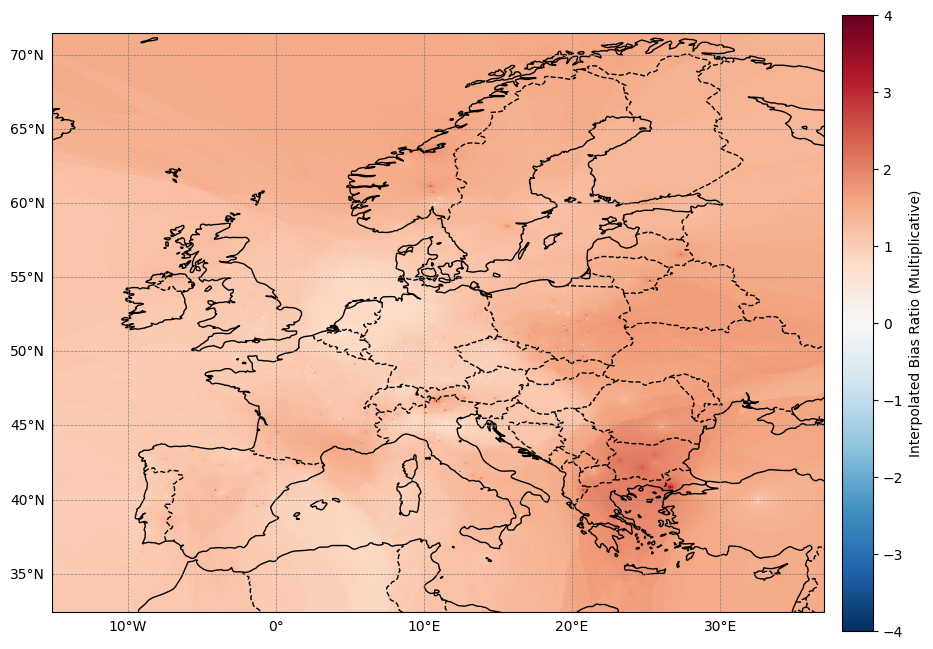

In [53]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias Ratio NetCDF File ===
bias_netcdf_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias ratio
interpolated_bias_ratio = ds_bias["Interpolated_Bias_Ratio"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -4 # Set minimum scale for bias ratio
cbar_max = 4  # Set maximum scale for bias ratio

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias ratio
im = ax.pcolormesh(lon, lat, interpolated_bias_ratio, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias Ratio (Multiplicative)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

In [55]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_ratio_nc_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"
corrected_nc_path = "BaseCase_Corrected_PM25_rh50_Y_MUL.nc"

# === Load the Original Modeled PM₂.₅ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_ratio_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

    # Load the interpolated bias ratio
    interpolated_bias_ratio = bias_nc.variables["Interpolated_Bias_Ratio"][:]

    # === Apply Multiplicative Bias Correction ===
    # Ensure bias ratio does not contain values too close to zero
    min_bias_threshold = 0.1  # Prevent extreme scaling
    interpolated_bias_ratio = np.maximum(interpolated_bias_ratio, min_bias_threshold)

    # Correct PM₂.₅
    pm25_corrected = pm25_original * interpolated_bias_ratio  # Multiplicative correction

    # === Save the Corrected PM₂.₅ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_rh50_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original PM₂.₅ variable
        pm25_var.setncatts(original_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_corrected  # Store corrected PM₂.₅

print(" Multiplicative Bias Correction Completed Successfully!")
print(" Corrected PM₂.₅ NetCDF file saved as:", corrected_nc_path)

 Multiplicative Bias Correction Completed Successfully!
 Corrected PM₂.₅ NetCDF file saved as: BaseCase_Corrected_PM25_rh50_Y_MUL.nc


In [57]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_PM25_rh50_Y_MUL.nc"  # Your original file
output_file = "BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_rh50_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")


 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

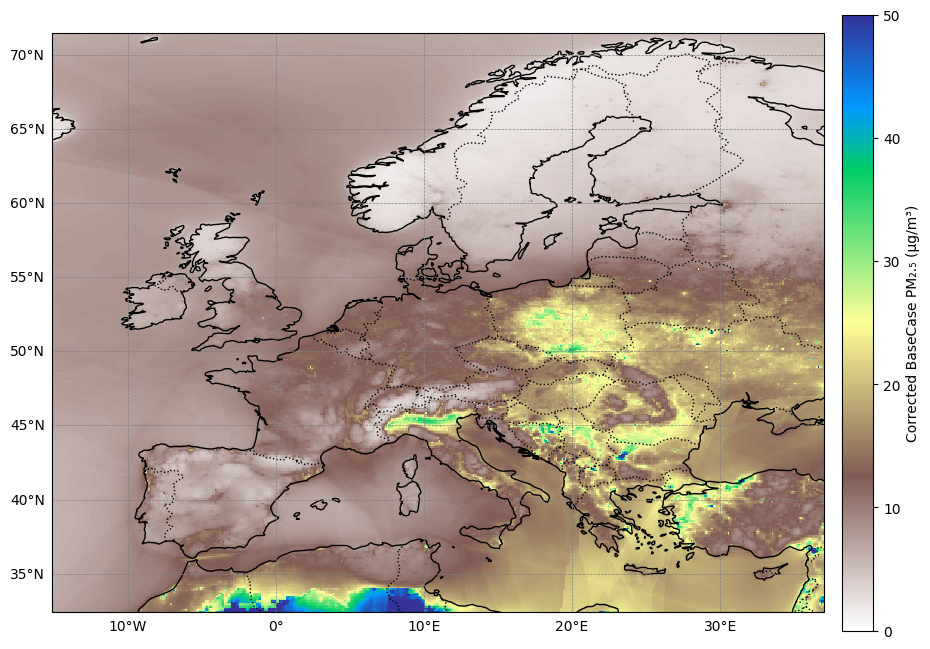

In [58]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "BaseCase_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected BaseCase PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()


In [59]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2022.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "BaseCase_PM25_rh50_Y_IDW_MUL.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected_PM25_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load model grid & PM₂.₅ data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    pm25_scenario_perturbed = scen_nc.variables["SURF_ug_PM25_rh50"][:]  # Perturbed Scenario PM₂.₅
    interpolated_bias_ratios = bias_nc.variables["Interpolated_Bias_Ratio"][:]  # Interpolated OBS / MOD ratios

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional safeguard
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    pm25_scenario_corrected = pm25_scenario_perturbed * interpolated_bias_ratios

    # === Save Corrected Scenario ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy metadata attributes from the original scenario file
        pm25_var.setncatts(scen_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF saved as:", corrected_scenario_nc_path)


Multiplicative IDW Bias Correction Applied Successfully!
Corrected PM₂.₅ Scenario NetCDF saved as: Scenario_Corrected_PM25_MUL.nc


In [60]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_PM25_MUL.nc"  # Your original file
output_file = "Scen_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: Scen_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators version 5.

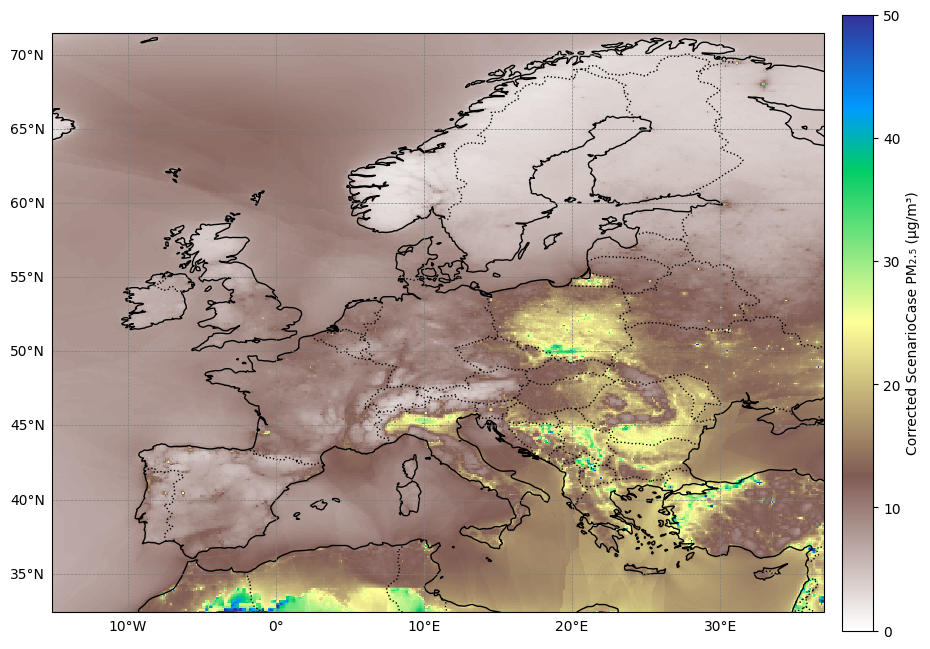

In [61]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_UoA_PM25_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected ScenarioCase PM₂.₅ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()